In [ ]:
### Yiğit Şevki Kaplan
### 22243810049
### 19.11.2025

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("pulsar_stars2.csv")

In [ ]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [ ]:
df.shape

(17898, 9)

In [ ]:
+

,count
target_class,
0,16259
1,1639


In [ ]:
df['target_class'].value_counts()/len(df)

,count
target_class,
0,0.908426
1,0.091574


In [ ]:
# Algoritma sürekli 0 verirse başarı oranı 91% olarak görünür.
# Algoritmamızın 91% den daha iyi bir başarı oranı sağlaması gerekiyor.

# Örn. Üretim hattında defective ürün bulmaya çalışıyoruz. Sürekli
# 1(non-defective) başarı oranı yine fazla çıkacaktır.

In [ ]:
df.isnull().sum()

,0
Mean of the integrated profile,0
Standard deviation of the integrated profile,0
Excess kurtosis of the integrated profile,0
Skewness of the integrated profile,0
Mean of the DM-SNR curve,0
Standard deviation of the DM-SNR curve,0
Excess kurtosis of the DM-SNR curve,0
Skewness of the DM-SNR curve,0
target_class,0


In [ ]:
# 0 NULL variable

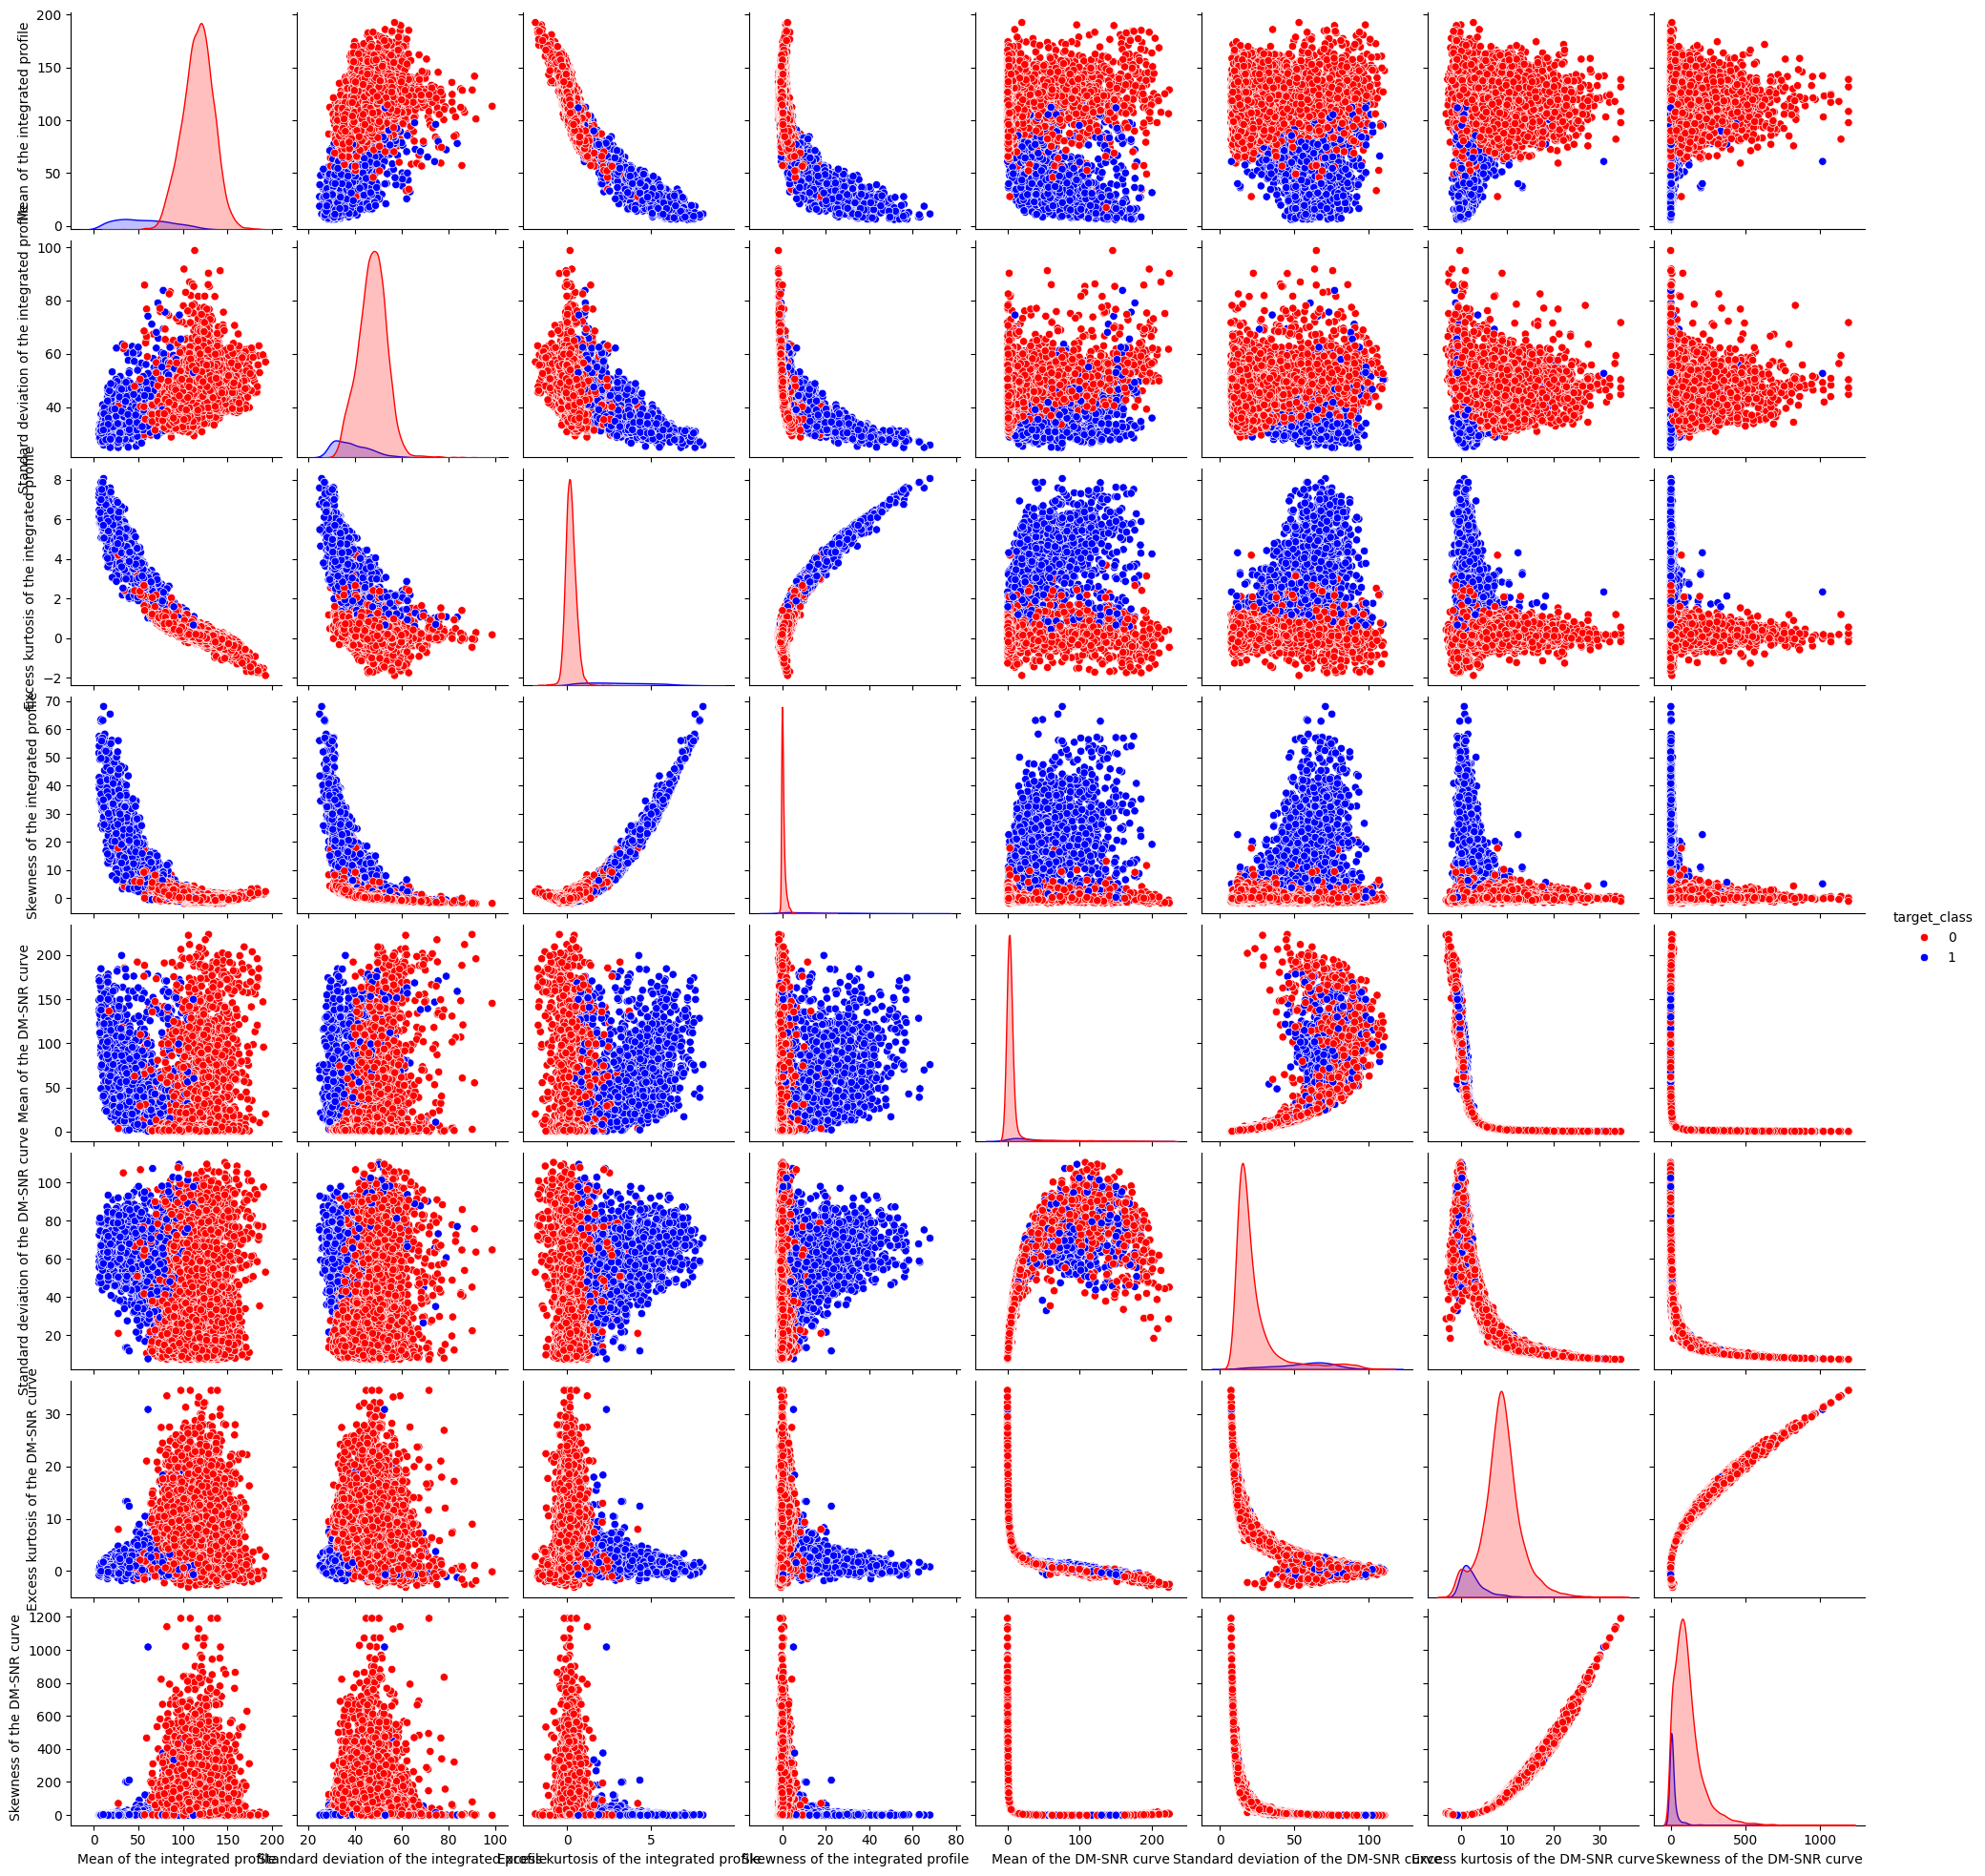

In [ ]:
sns.pairplot(df,hue='target_class', palette = ['red', 'blue'])

In [ ]:
# Amacımız kırmızılar ile mavileri ayırmak

In [ ]:
X = df.drop(['target_class'], axis = 1)
Y = df['target_class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, stratify = Y, random_state = 4)

In [ ]:
# 0 ların oranı 0.91, 1 ler 0.09 du. Bu oranı korumak için 'stratify' komutu kullandık.
# Test, train setlerinde bu oran korundu, hala rastgelelik var.

In [ ]:
svc = svm.SVC()

In [ ]:
# SVM (Support Vector Machine), SVC (Support Vector Classifier)
# Hiç bir parametre girilmezse; kernel = radial basis, c = 1.

In [ ]:
svc.fit(x_train, y_train)

SVC()

In [ ]:
y_pred = svc.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.9754189944134078

In [ ]:
#its bigger than 0.91, acceptable.

In [ ]:
svc_c100 = svm.SVC(C = 100)

In [ ]:
svc_c100.fit(x_train, y_train)

SVC(C=100)

In [ ]:
y_pred_c100 = svc_c100.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_c100)

0.977877094972067

In [ ]:
linear_svc = svm.SVC(kernel = 'linear', C = 10)

In [ ]:
linear_svc.fit(x_train, y_train)

SVC(C=10, kernel='linear')

In [ ]:
y_pred_linear = linear_svc.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_linear)

0.9805586592178771

In [ ]:
poly_svc = svm.SVC(kernel = 'poly', C=49)

In [ ]:
poly_svc.fit(x_train, y_train)

SVC(C=49, kernel='poly')

In [ ]:
y_pred_poly = poly_svc.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_poly)

0.9740782122905028

In [ ]:
poly_svc_c10 = svm.SVC(kernel = 'poly', C=10)

In [ ]:
poly_svc_c10.fit(x_train,y_train)

SVC(C=10, kernel='poly')

In [ ]:
y_pred_poly_c10 = poly_svc_c10.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_poly_c10)

0.9727374301675977

In [ ]:
sigmoid_svc = svm.SVC(kernel = 'sigmoid', C=10)

In [ ]:
sigmoid_svc.fit(x_train,y_train)

SVC(C=10, kernel='sigmoid')

In [ ]:
y_pred_sigmoid = sigmoid_svc.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_sigmoid)

0.9217877094972067

In [ ]:
sigmoid_svc_c49 = svm.SVC(kernel = 'sigmoid', C=49)

In [ ]:
sigmoid_svc_c49.fit(x_train, y_train)

SVC(C=49, kernel='sigmoid')

In [ ]:
y_pred_sigmoid_c49 = sigmoid_svc_c49.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_sigmoid_c49)

0.9217877094972067

In [ ]:
# according to all best match is c=10, kernel = 'linear'